# Pizza Place Sales Analysis

**Dataset:** Pizza Place Sales.zip (Orders, Order Details, Pizzas, Pizza Types)
**Period covered:** A full year (2015) of transactions from a fictitious pizza restaurant.



## Section 1: Setup & Imports

We only need three libraries for this analysis:
- `pandas` — loading, joining, and aggregating the CSVs
- `matplotlib` — charts
- `numpy` — a couple of numeric helpers (rounding, percentages)


In [35]:
# ============================================================
# SECTION 1: SETUP & IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings so wide tables (e.g. all 32 pizza types) don't get truncated
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# Consistent, readable chart style for every plot in this notebook
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.facecolor'] = 'white'

print("Libraries loaded.")

Libraries loaded.


## Section 2: Load the Four Source Tables

Per the data dictionary, the four files relate to each other like this:

| Table | Key(s) | Links to |
|---|---|---|
| `orders` | `order_id` | joined to `order_details` |
| `order_details` | `order_id`, `pizza_id` | joined to `orders` and `pizzas` |
| `pizzas` | `pizza_id`, `pizza_type_id` | joined to `order_details` and `pizza_types` |
| `pizza_types` | `pizza_type_id` | joined to `pizzas` |

So the join path is: **order_details → orders** (adds date/time) and
**order_details → pizzas → pizza_types** (adds size/price and name/category/ingredients).


In [36]:
# ============================================================
# SECTION 2: LOAD THE FOUR SOURCE TABLES
# ============================================================

orders = pd.read_csv('orders.csv')
order_details = pd.read_csv('order_details.csv')
pizzas = pd.read_csv('pizzas.csv')

# pizza_types.csv contains characters (e.g. accented ingredient names like
# "Brie Carre") that aren't valid UTF-8, so we read it with latin-1 encoding
# to avoid a UnicodeDecodeError.
pizza_types = pd.read_csv('pizza_types.csv', encoding='latin-1')

print(f"orders:        {orders.shape[0]:,} rows")
print(f"order_details: {order_details.shape[0]:,} rows")
print(f"pizzas:        {pizzas.shape[0]:,} rows")
print(f"pizza_types:   {pizza_types.shape[0]:,} rows")

orders:        21,350 rows
order_details: 48,620 rows
pizzas:        96 rows
pizza_types:   32 rows


## Section 3: Data Quality Check

Before joining anything, it's worth confirming there are no missing values or obvious
surprises hiding in the raw tables — a bad join is much harder to debug than a bad column.


In [37]:
# ============================================================
# SECTION 3: DATA QUALITY CHECK
# ============================================================

# .isna().sum() counts missing values per column across all four tables.
# If any of these come back non-zero, we'd need to decide whether to drop
# or impute before joining.
for name, table in [('orders', orders), ('order_details', order_details),
                     ('pizzas', pizzas), ('pizza_types', pizza_types)]:
    missing = table.isna().sum().sum()
    print(f"{name:<15} missing values: {missing}")

# Sanity-check the categorical fields we'll group by later
print("\nPizza sizes: ", sorted(pizzas['size'].unique()))
print("Pizza categories:", sorted(pizza_types['category'].unique()))

orders          missing values: 0
order_details   missing values: 0
pizzas          missing values: 0
pizza_types     missing values: 0

Pizza sizes:  ['L', 'M', 'S', 'XL', 'XXL']
Pizza categories: ['Chicken', 'Classic', 'Supreme', 'Veggie']


**Insight:** All four tables are clean — no missing values anywhere, and the size/category
fields only contain the values we'd expect (5 sizes, 4 categories). No cleaning needed before
joining.

## Section 4: Join Into One Analytical Dataframe

Following the tip in the brief, we merge all four tables into a single wide dataframe, `df`,
where **each row is one line item of one order** (one pizza, one size, at whatever quantity
was ordered). This is the natural grain of `order_details`, so we merge everything else onto it.


In [38]:
# ============================================================
# SECTION 4: JOIN INTO ONE ANALYTICAL DATAFRAME
# ============================================================

# ── Step 1: order_details + pizzas ──
# Adds size and price for each pizza_id ordered
df = order_details.merge(pizzas, on='pizza_id', how='left')

# ── Step 2: + pizza_types ──
# Adds the human-readable name, category, and ingredients
df = df.merge(pizza_types, on='pizza_type_id', how='left')

# ── Step 3: + orders ──
# Adds the date and time each order was placed
df = df.merge(orders, on='order_id', how='left')

# ── Step 4: derive the columns every later question needs ──
# revenue = unit price x quantity ordered, per line item
df['revenue'] = df['quantity'] * df['price']

# Parse date/time once here so every later cell can just reuse these columns
df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month_name()
df['month_num'] = df['date'].dt.month
df['hour'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.hour

print(f"Merged dataframe: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Merged dataframe: 48,620 rows x 17 columns


,order_details_id,order_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients,date,time,revenue,day_of_week,month,month_num,hour
0,1,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",2015-01-01,11:38:36,13.25,Thursday,January,1,11
1,2,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",2015-01-01,11:57:40,16.00,Thursday,January,1,11
2,3,2,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",2015-01-01,11:57:40,18.50,Thursday,January,1,11
3,4,2,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",2015-01-01,11:57:40,20.75,Thursday,January,1,11
4,5,2,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",2015-01-01,11:57:40,16.00,Thursday,January,1,11


**Insight:** The merged dataframe has 48,620 rows — one per pizza line item — which matches
`order_details` exactly, confirming the joins didn't duplicate or drop any rows (all keys matched
cleanly on both sides).

## Section 5: Total Revenue

In [39]:
# ============================================================
# SECTION 5: TOTAL REVENUE
# ============================================================

# Summing the pre-computed 'revenue' column (price x quantity) across every
# line item gives total sales for the full year
total_revenue = df['revenue'].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $817,860.05


**Insight:** The pizza place generated **\$817,860.05** in total revenue over the year.

## Section 6: Total Quantity Sold

In [40]:
# ============================================================
# SECTION 6: TOTAL QUANTITY SOLD
# ============================================================

# 'quantity' already accounts for repeated pizzas within the same order
# (e.g. "2x Hawaiian M" is one row with quantity=2, not two rows)
total_quantity = df['quantity'].sum()

print(f"Total Pizzas Sold: {total_quantity:,}")

Total Pizzas Sold: 49,574


**Insight:** **49,574 individual pizzas** were sold across the year — roughly 136 pizzas a day on average.

## Section 7: Total Orders

In [41]:
# ============================================================
# SECTION 7: TOTAL ORDERS
# ============================================================

# nunique() on order_id (not len(orders), though they're equal here) — this
# is the more defensive way to count distinct orders in case of duplicates
total_orders = df['order_id'].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 21,350


**Insight:** **21,350 orders** were placed. Combined with the totals above, that's an average of **2.32 pizzas per order** and **\$38.31 in revenue per order**.

## Section 8: How Many Pizza Types Are Sold

In [42]:
# ============================================================
# SECTION 8: NUMBER OF PIZZA TYPES
# ============================================================

num_pizza_types = pizza_types.shape[0]
num_sizes = pizzas.shape[0]  # each type x each size it's offered in

print(f"Distinct pizza types (recipes): {num_pizza_types}")
print(f"Distinct sellable SKUs (type x size): {num_sizes}")

Distinct pizza types (recipes): 32
Distinct sellable SKUs (type x size): 96


**Insight:** The menu has **32 distinct pizza recipes**, each offered in up to 5 sizes, giving **96 orderable SKUs** in total.

## Section 9: Average Price of the Pizzas

In [43]:
# ============================================================
# SECTION 9: AVERAGE PRICE
# ============================================================

# Average listed price across the 96 SKUs (not weighted by how often each sells)
avg_menu_price = pizzas['price'].mean()

# For comparison: the average price actually paid per pizza sold (revenue-weighted)
avg_realized_price = df['revenue'].sum() / df['quantity'].sum()

print(f"Average menu price (unweighted):        ${avg_menu_price:.2f}")
print(f"Average price actually paid per pizza:   ${avg_realized_price:.2f}")

Average menu price (unweighted):        $16.44
Average price actually paid per pizza:   $16.50


**Insight:** The average menu price is **\$16.44**, almost identical to the **\$16.50** customers actually pay on average per pizza — customers aren't skewing heavily toward the cheap or expensive end of the menu.

## Section 10: Peak Hours of Sales

We group every line item by the hour it was ordered (extracted from `time` in Section 4)
and sum revenue per hour to see when the restaurant is busiest.


Top 5 busiest hours by revenue:
hour
12    111877.90
13    106065.70
18     89296.85
17     86237.45
19     72628.90
Name: revenue, dtype: float64


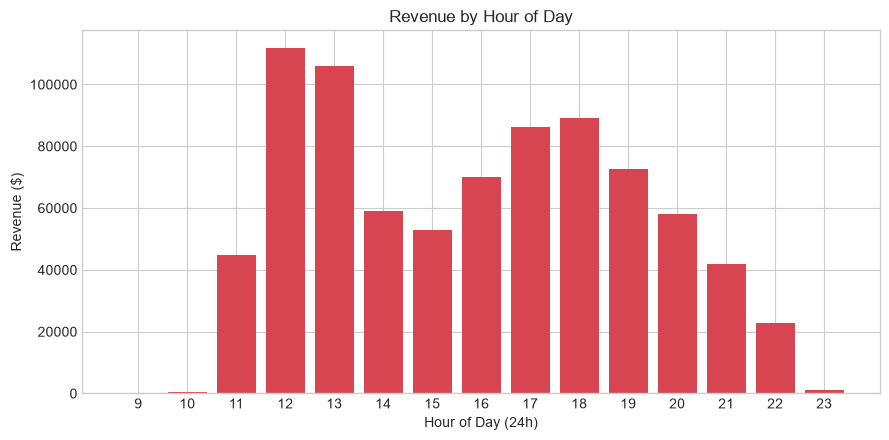

In [44]:
# ============================================================
# SECTION 10: PEAK HOURS OF SALES
# ============================================================

hourly_revenue = df.groupby('hour')['revenue'].sum().sort_values(ascending=False)

print("Top 5 busiest hours by revenue:")
print(hourly_revenue.head())

# Visualize the full daily curve, not just the top 5, so we can see the shape
plt.figure(figsize=(9, 4.5))
full_hourly = df.groupby('hour')['revenue'].sum()
plt.bar(full_hourly.index, full_hourly.values, color='#d64550')
plt.xlabel('Hour of Day (24h)')
plt.ylabel('Revenue ($)')
plt.title('Revenue by Hour of Day')
plt.xticks(range(9, 24))
plt.tight_layout()
plt.show()

**Insight:** There are two clear peaks — a **lunch rush at 12:00–13:00** (the single busiest hour)
and a smaller **dinner rush from 17:00–19:00**. Revenue drops off sharply before 11am and after 9pm.
This is a classic two-peak restaurant pattern, useful for staffing decisions: the kitchen needs
maximum coverage around noon and again around 6pm.

## Section 11: Sales by Day of the Week

day_of_week
Monday       107329.55
Tuesday      114133.80
Wednesday    114408.40
Thursday     123528.50
Friday       136073.90
Saturday     123182.40
Sunday        99203.50
Name: revenue, dtype: float64

Best day: Friday ($136,073.90)
Worst day: Sunday ($99,203.50)


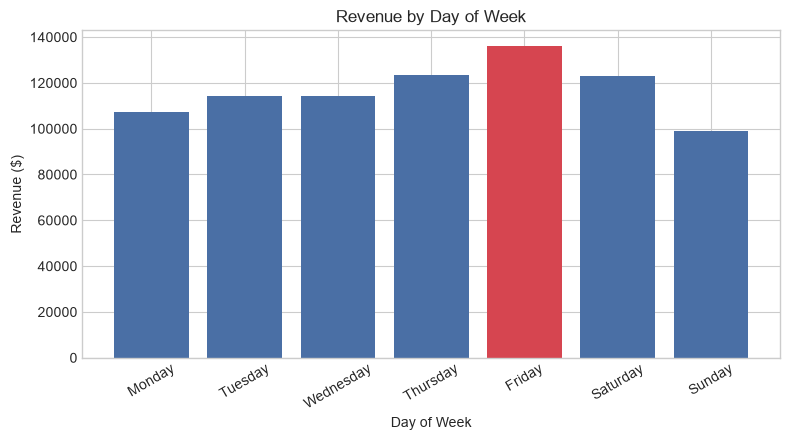

In [45]:
# ============================================================
# SECTION 11: SALES BY DAY OF THE WEEK
# ============================================================

# Reindex to force calendar order (Mon->Sun) instead of alphabetical,
# which is what groupby would give us by default
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_revenue = df.groupby('day_of_week')['revenue'].sum().reindex(day_order)

print(daily_revenue)
print(f"\nBest day: {daily_revenue.idxmax()} (${daily_revenue.max():,.2f})")
print(f"Worst day: {daily_revenue.idxmin()} (${daily_revenue.min():,.2f})")

plt.figure(figsize=(8, 4.5))
colors = ['#d64550' if d == daily_revenue.idxmax() else '#4a6fa5' for d in day_order]
plt.bar(daily_revenue.index, daily_revenue.values, color=colors)
plt.xlabel('Day of Week')
plt.ylabel('Revenue ($)')
plt.title('Revenue by Day of Week')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Insight:** **Friday is the strongest day** (\$136,074), consistent with people ordering pizza
to kick off the weekend, followed by Thursday and Saturday. **Sunday is the quietest** day —
about 27% lower than Friday. Revenue is fairly flat Monday through Wednesday before building
toward the Friday peak.

## Section 12: Top 5 Bestselling Pizzas

"Bestselling" is ambiguous — it can mean highest **quantity sold** or highest **revenue generated**.
Since a large pizza sold once brings in more money than a small one, these two rankings don't
always agree, so we check both.


Top 5 by QUANTITY sold:
name
The Classic Deluxe Pizza      2453
The Barbecue Chicken Pizza    2432
The Hawaiian Pizza            2422
The Pepperoni Pizza           2418
The Thai Chicken Pizza        2371
Name: quantity, dtype: int64

Top 5 by REVENUE generated:
name
The Thai Chicken Pizza          43434.25
The Barbecue Chicken Pizza      42768.00
The California Chicken Pizza    41409.50
The Classic Deluxe Pizza        38180.50
The Spicy Italian Pizza         34831.25
Name: revenue, dtype: float64


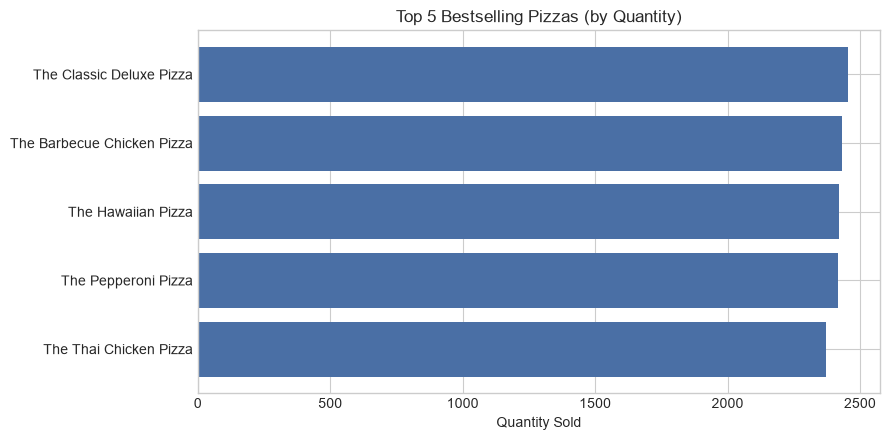

In [46]:
# ============================================================
# SECTION 12: TOP 5 BESTSELLING PIZZAS
# ============================================================

top5_by_qty = df.groupby('name')['quantity'].sum().sort_values(ascending=False).head(5)
top5_by_revenue = df.groupby('name')['revenue'].sum().sort_values(ascending=False).head(5)

print("Top 5 by QUANTITY sold:")
print(top5_by_qty)
print("\nTop 5 by REVENUE generated:")
print(top5_by_revenue)

plt.figure(figsize=(9, 4.5))
plt.barh(top5_by_qty.index[::-1], top5_by_qty.values[::-1], color='#4a6fa5')
plt.xlabel('Quantity Sold')
plt.title('Top 5 Bestselling Pizzas (by Quantity)')
plt.tight_layout()
plt.show()

**Insight:** The two rankings mostly overlap but aren't identical. **The Classic Deluxe Pizza**
sells the most units (2,453) but ranks only 4th in revenue, while **The Thai Chicken Pizza** and
**The Barbecue Chicken Pizza** aren't the top sellers by volume but generate the most money —
they're premium-priced Chicken-category pizzas. Chicken-category pizzas show up disproportionately
in the revenue leaderboard, suggesting they carry a higher price point that offsets slightly
lower unit sales.

## Section 13: Sales by Month

    month  revenue
  January 69793.30
 February 65159.60
    March 70397.10
    April 68736.80
      May 71402.75
     June 68230.20
     July 72557.90
   August 68278.25
September 64180.05
  October 64027.60
 November 70395.35
 December 64701.15


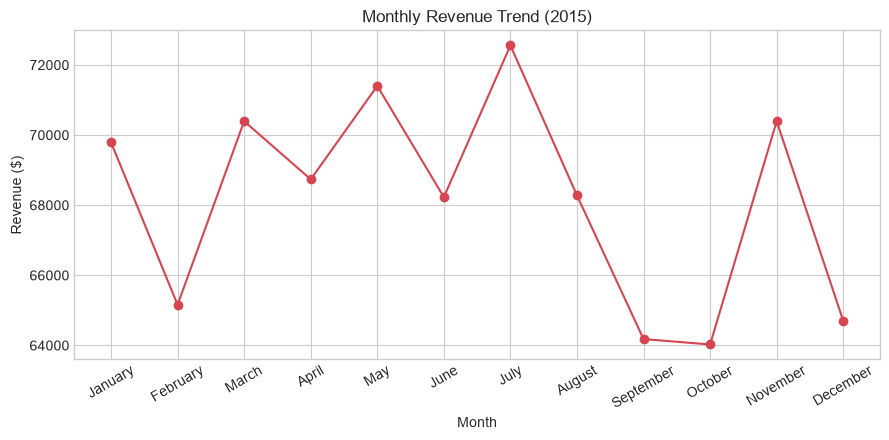

In [47]:
# ============================================================
# SECTION 13: SALES BY MONTH
# ============================================================

# Sort by month_num (not the month name string) to keep chronological order
monthly_revenue = (df.groupby(['month_num', 'month'])['revenue']
                      .sum()
                      .reset_index()
                      .sort_values('month_num'))

print(monthly_revenue[['month', 'revenue']].to_string(index=False))

plt.figure(figsize=(9, 4.5))
plt.plot(monthly_revenue['month'], monthly_revenue['revenue'], marker='o', color='#d64550')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.title('Monthly Revenue Trend (2015)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Insight:** Monthly revenue is **remarkably stable** across the year — every month falls between
roughly \$64,000 and \$72,600, a range of only about 13%. There's no strong seasonal trend or
growth/decline pattern; **July is the single highest month** (\$72,558, possibly summer/July 4th
foot traffic) and **October is the lowest** (\$64,028). This flatness suggests the business had
a stable, mature customer base throughout the year rather than growing or seasonal demand.

## Section 14: Pizza Types That Aren't Doing Well

We look at this from both ends: which pizzas sell the least revenue, and which sell the fewest units.


5 lowest-revenue pizzas:
name
The Brie Carre Pizza         11588.50
The Green Garden Pizza       13955.75
The Spinach Supreme Pizza    15277.75
The Mediterranean Pizza      15360.50
The Spinach Pesto Pizza      15596.00
Name: revenue, dtype: float64

5 lowest-quantity pizzas:
name
The Brie Carre Pizza         490
The Mediterranean Pizza      934
The Calabrese Pizza          937
The Spinach Supreme Pizza    950
The Soppressata Pizza        961
Name: quantity, dtype: int64


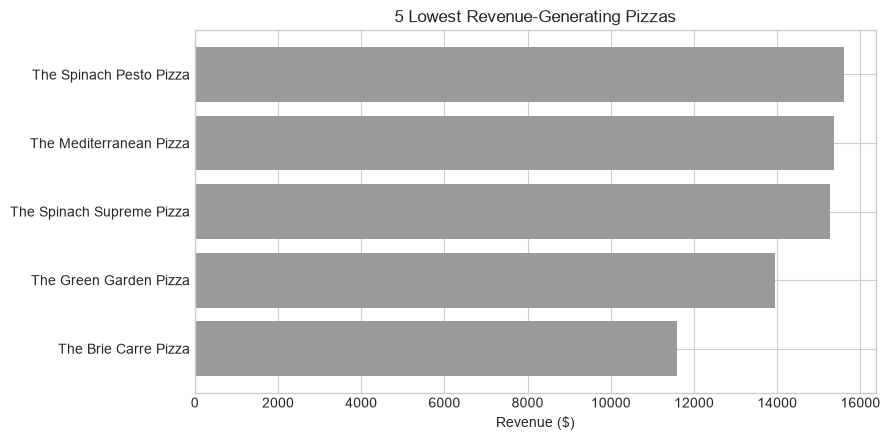

In [48]:
# ============================================================
# SECTION 14: UNDERPERFORMING PIZZA TYPES
# ============================================================

bottom5_revenue = df.groupby('name')['revenue'].sum().sort_values(ascending=True).head(5)
bottom5_qty = df.groupby('name')['quantity'].sum().sort_values(ascending=True).head(5)

print("5 lowest-revenue pizzas:")
print(bottom5_revenue)
print("\n5 lowest-quantity pizzas:")
print(bottom5_qty)

plt.figure(figsize=(9, 4.5))
plt.barh(bottom5_revenue.index, bottom5_revenue.values, color='#9a9a9a')
plt.xlabel('Revenue ($)')
plt.title('5 Lowest Revenue-Generating Pizzas')
plt.tight_layout()
plt.show()

**Insight:** **The Brie Carre Pizza** is the weakest performer on both measures — lowest revenue
(\$11,589) *and* lowest quantity sold (490 units), roughly a fifth of what the top sellers move.
Four of the five worst pizzas by revenue are **Veggie-category** pizzas (Green Garden, Spinach
Supreme, Mediterranean, Spinach Pesto), suggesting the Veggie category as a whole is underperforming
relative to Chicken, Classic, and Supreme — worth checking in the category breakdown below.

## Section 15: Going Further — Extra Exploration

The brief invites deeper exploration beyond the core questions. A few angles worth checking:
- Does the "Veggie underperforms" hypothesis from Section 14 hold up at the category level?
- Which **size** generates the most revenue?
- How big is the busiest day of the year vs. the slowest?


Revenue by category:
  Classic    $220,053.10  (26.9%)
  Supreme    $208,197.00  (25.5%)
  Chicken    $195,919.50  (24.0%)
  Veggie     $193,690.45  (23.7%)


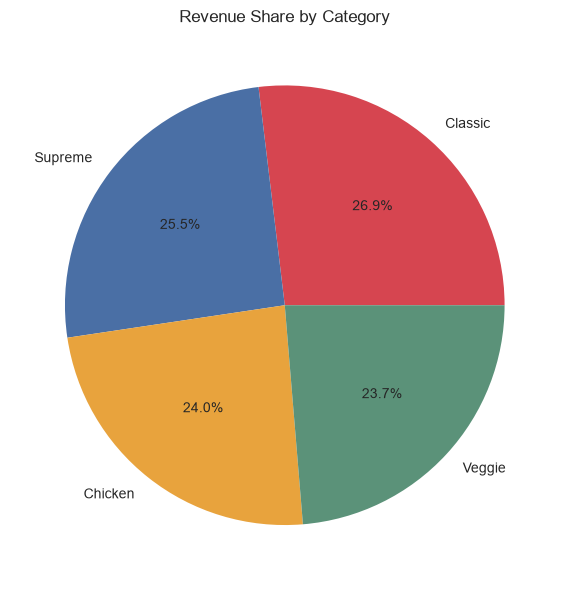

In [49]:
# ============================================================
# SECTION 15A: REVENUE BY CATEGORY
# ============================================================

category_revenue = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
category_share = (category_revenue / category_revenue.sum() * 100).round(1)

print("Revenue by category:")
for cat in category_revenue.index:
    print(f"  {cat:<10} ${category_revenue[cat]:>10,.2f}  ({category_share[cat]}%)")

plt.figure(figsize=(6, 6))
plt.pie(category_revenue.values, labels=category_revenue.index, autopct='%1.1f%%',
        colors=['#d64550', '#4a6fa5', '#e8a33d', '#5b9279'])
plt.title('Revenue Share by Category')
plt.tight_layout()
plt.show()

**Insight:** The four categories are actually **fairly balanced** — Veggie brings in 23.7% of
revenue against a roughly-even 25% share if all categories were equal, so it's the weakest
category but not dramatically so. The individual "worst pizzas" list in Section 14 is a
sharper way to spot underperformers than category alone; a handful of specific recipes (Brie
Carre, Mediterranean) are dragging the Veggie average down more than the category as a whole
being unpopular.

In [50]:
# ============================================================
# SECTION 15B: REVENUE BY SIZE
# ============================================================

size_order = ['S', 'M', 'L', 'XL', 'XXL']
size_revenue = df.groupby('size')['revenue'].sum().reindex(size_order)
size_qty = df.groupby('size')['quantity'].sum().reindex(size_order)

print("Revenue and quantity by size:")
print(pd.DataFrame({'revenue': size_revenue, 'quantity': size_qty}))

Revenue and quantity by size:
        revenue  quantity
size                     
S     178076.50     14403
M     249382.25     15635
L     375318.70     18956
XL     14076.00       552
XXL     1006.60        28


**Insight:** **Large is the dominant size**, driving 46% of all revenue (\$375,319) despite
being only one of five size options — customers clearly gravitate to L over M or S. XL and XXL
are niche: combined they're under 2% of revenue, so they likely only exist for a couple of
specialty pizza types rather than being offered menu-wide.

In [51]:
# ============================================================
# SECTION 15C: BUSIEST vs SLOWEST DAY OF THE YEAR
# ============================================================

daily_totals = df.groupby('date')['revenue'].sum()

busiest_date = daily_totals.idxmax()
slowest_date = daily_totals.idxmin()

print(f"Busiest single day: {busiest_date.date()} — ${daily_totals.max():,.2f}")
print(f"Slowest single day: {slowest_date.date()} — ${daily_totals.min():,.2f}")
print(f"\nAverage daily revenue: ${daily_totals.mean():,.2f}")
print(f"Average items per order (across the year): {df.groupby('order_id')['quantity'].sum().mean():.2f}")

Busiest single day: 2015-11-27 — $4,422.45
Slowest single day: 2015-03-22 — $1,259.25

Average daily revenue: $2,284.53
Average items per order (across the year): 2.32


**Insight:** The single busiest day was **November 27, 2015** (\$4,422 — this is the day after
Thanksgiving in the US, a plausible takeout-heavy holiday), nearly **3.5x** an average day
(\$2,241) and **3.5x** the slowest day (March 22, \$1,259, an otherwise unremarkable Sunday).
This lines up with the earlier finding that Friday/weekend-adjacent days outperform — holiday
periods appear to amplify that same effect.

## Summary of Key Insights

- **Scale:** \$817,860 in total revenue from 49,574 pizzas across 21,350 orders (avg. \$38.31 / order, 2.32 pizzas / order).
- **Menu:** 32 pizza recipes across 4 categories, sold in up to 5 sizes (96 SKUs); average price \$16.44.
- **Timing:** Two daily peaks — lunch (12–1pm) and dinner (5–7pm). **Friday** is the best day of the week, **Sunday** the weakest.
- **Seasonality:** Revenue is flat year-round (no strong trend); July is the best month, October the weakest — the gap between them is only ~13%.
- **Bestsellers:** Classic Deluxe sells the most units, but Thai Chicken and Barbecue Chicken generate the most revenue thanks to higher price points.
- **Underperformers:** Brie Carre Pizza is the weakest pizza on the menu by both units and revenue; Veggie-category pizzas dominate the bottom of the list, though the category overall isn't dramatically behind the others.
- **Size matters:** Large is the clear preference, driving 46% of all revenue; XL/XXL are marginal.
- **Holiday effect:** The day after Thanksgiving was the single best sales day of the year, ~3.5x an average day.

**Possible next steps for the business:** consider retiring or reworking the Brie Carre Pizza,
lean into Large-size promotions, and staff up specifically for the Friday dinner rush and
Thanksgiving weekend.
